In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [ ]:
#import libraries for Deep learning
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam, SGD, RMSprop

In [ ]:
diabetes_df = pd.read_csv('/content/diabetes.csv')
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes_df.columns = [
    "times_pregnant", "glucose_tolerance_test", "blood_pressure", "skin_thickness",
    "insulin", "bmi", "pedigree_function", "age", "has_diabetes"
]
diabetes_df.head()

,times_pregnant,glucose_tolerance_test,blood_pressure,skin_thickness,insulin,bmi,pedigree_function,age,has_diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(diabetes_df.shape)
diabetes_df.sample(5)

(768, 9)


,times_pregnant,glucose_tolerance_test,blood_pressure,skin_thickness,insulin,bmi,pedigree_function,age,has_diabetes
44,7,159,64,0,0,27.4,0.294,40,0
343,5,122,86,0,0,34.7,0.290,33,0
263,3,142,80,15,0,32.4,0.200,63,0
549,4,189,110,31,0,28.5,0.680,37,0
680,2,56,56,28,45,24.2,0.332,22,0


In [ ]:
X = diabetes_df.drop("has_diabetes", axis = 1)
y = diabetes_df["has_diabetes"]



,has_diabetes
0,1
1,0
2,1
3,0
4,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state=42)

In [ ]:
np.mean(y), np.mean(1-y)


(np.float64(0.3489583333333333), np.float64(0.6510416666666666))

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200)

In [ ]:
y_pred_clf_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)

print('accuracy is {:.3f}'.format(accuracy_score(y_test, y_pred_clf_rf)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test, y_pred_prob_rf[:,1])))

accuracy is 0.729
roc-auc is 0.807


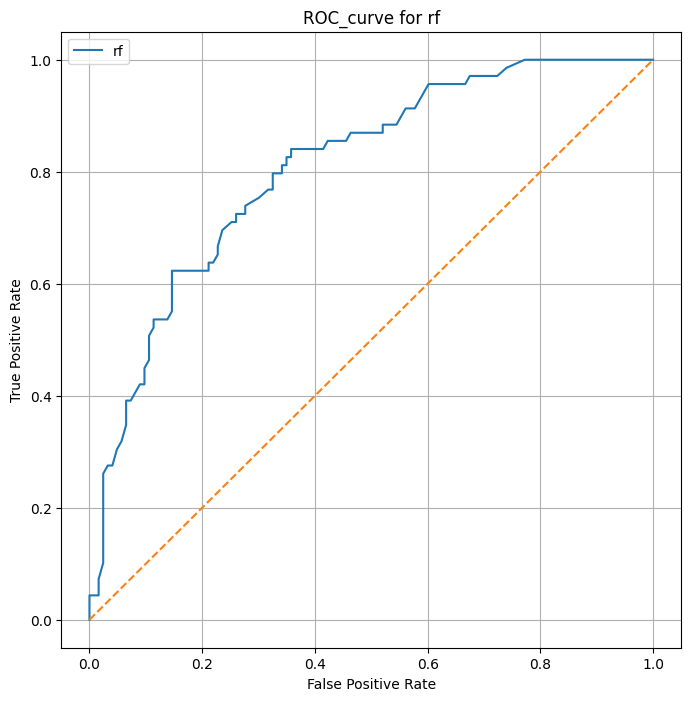

In [ ]:
def plot_roc(y_test, y_pred, model_name):
    fpr, tpr, thr = roc_curve(y_test, y_pred)

    plt.figure(figsize = (8,8))
    plt.plot(fpr, tpr, label = model_name)
    plt.plot([0,1], [0,1], '--')

    plt.title(f"ROC_curve for {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

plot_roc(y_test, y_pred_prob_rf[:,1], 'rf')

In [ ]:
normalizer = StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

In [ ]:
model_1 = Sequential()
model_1.add(Dense(12, activation = 'sigmoid', input_dim=X_train.shape[1]))
model_1.add(Dense(1, activation='sigmoid'))

In [ ]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_1.compile(
    optimizer = SGD(learning_rate= 0.003),
    loss = "binary_crossentropy",
    metrics = ['accuracy']
)

run_hist_1 = model_1.fit(
    X_train_norm, y_train,
    validation_data = (X_test_norm, y_test),
    epochs = 200
)


Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6944 - loss: 0.5775 - val_accuracy: 0.6875 - val_loss: 0.5975
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6944 - loss: 0.5771 - val_accuracy: 0.6927 - val_loss: 0.5973
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6944 - loss: 0.5767 - val_accuracy: 0.6927 - val_loss: 0.5970
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6944 - loss: 0.5764 - val_accuracy: 0.6927 - val_loss: 0.5967
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6944 - loss: 0.5760 - val_accuracy: 0.6927 - val_loss: 0.5964
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6944 - loss: 0.5757 - val_accuracy: 0.6927 - val_loss: 0.5962
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6944 - loss: 0.5753 - val_accuracy: 0.6927 - val_loss: 0.5959
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6944 - loss: 0.5750 - val_accuracy: 0.

In [ ]:
y_pred_prob_nn_1 = model_1.predict(X_test_norm)
y_pred_clf_nn_1 = (y_pred_prob_nn_1 > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 


In [ ]:
y_pred_clf_nn_1[:10]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1]])

In [ ]:
y_pred_prob_nn_1[:10]

array([[0.43001574],
       [0.21945521],
       [0.16382904],
       [0.26603135],
       [0.4044807 ],
       [0.5366102 ],
       [0.11035227],
       [0.3091777 ],
       [0.49044764],
       [0.54322094]], dtype=float32)

accuracy is 0.698
roc-auc is 0.762


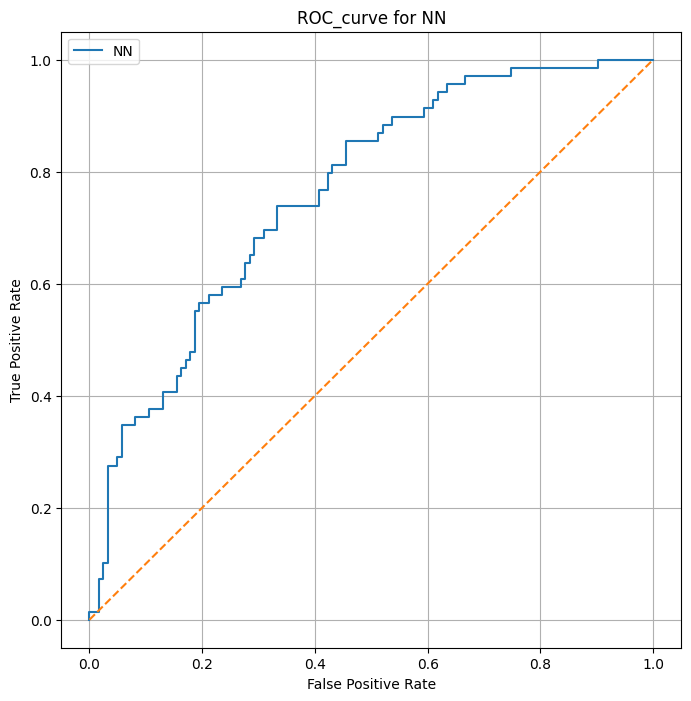

In [ ]:
print('accuracy is {:.3f}'.format(accuracy_score(y_test, y_pred_clf_nn_1)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test, y_pred_prob_nn_1)))

plot_roc(y_test, y_pred_prob_nn_1, 'NN')

In [ ]:
run_hist_1.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

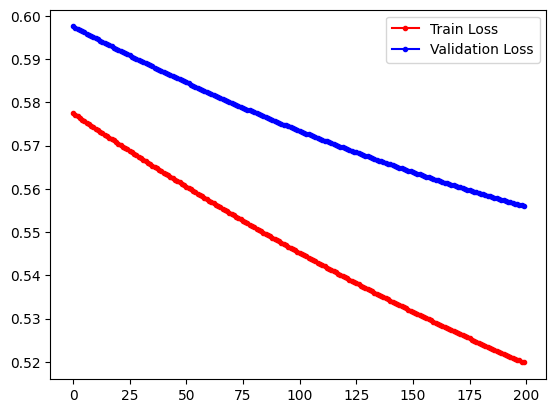

In [ ]:
plt.plot(run_hist_1.history['loss'], 'r', marker = '.', label = 'Train Loss')
plt.plot(run_hist_1.history['val_loss'], 'b', marker = '.', label = 'Validation Loss')
plt.legend()
plt.show()

In [ ]:
run_hist_1b = model_1.fit(
    X_train_norm, y_train,
    validation_data = (X_test_norm, y_test),
    epochs = 1000
)

Epoch 1/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7344 - loss: 0.5196 - val_accuracy: 0.6979 - val_loss: 0.5559
Epoch 2/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7344 - loss: 0.5194 - val_accuracy: 0.6979 - val_loss: 0.5557
Epoch 3/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7344 - loss: 0.5192 - val_accuracy: 0.6979 - val_loss: 0.5556
Epoch 4/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7344 - loss: 0.5190 - val_accuracy: 0.6979 - val_loss: 0.5554
Epoch 5/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7344 - loss: 0.5188 - val_accuracy: 0.6979 - val_loss: 0.5553
Epoch 6/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7344 - loss: 0.5185 - val_accuracy: 0.6979 - val_loss: 0.5551
Epoch 7/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7344 - loss: 0.5183 - val_accuracy: 0.6979 - val_loss: 0.5550
Epoch 8/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7361 - loss: 0.5181 - val_accur

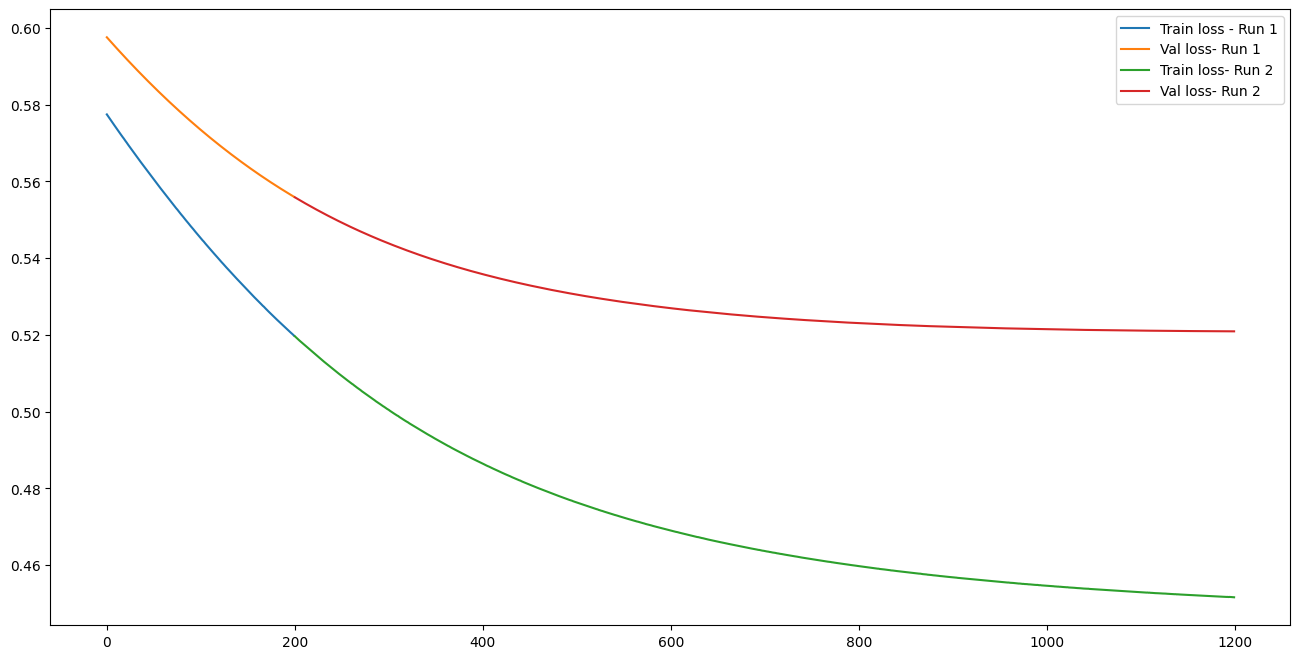

In [ ]:
n = len(run_hist_1.history['loss'])
plt.figure(figsize=(16,8))

# Run 1
plt.plot(run_hist_1.history["loss"], label="Train loss - Run 1")
plt.plot(run_hist_1.history["val_loss"], label="Val loss- Run 1")

# Run 2
plt.plot(range(n, n+len(run_hist_1b.history['loss'])), run_hist_1b.history['loss'], label="Train loss- Run 2")
plt.plot(range(n, n+len(run_hist_1b.history['val_loss'])), run_hist_1b.history['val_loss'], label="Val loss- Run 2")

plt.legend()
plt.show()